In [1]:
from fullsky_sims.fields import Fields
from scipy.interpolate import InterpolatedUnivariateSpline
import numpy as np
import matplotlib.pyplot as plt
from omegaqe.postborn import pb22_kappa_ps

In [6]:
# lss cache to False to create gal map on spot
# cmb cache to True to stop it from doing lensing rec on fly (will give object a kappa map directly later)
exp = "ACT"
tracers = "kg"
%time field = Fields(exp, fields=tracers, use_lss_cache=False, use_cmb_cache=True, nthreads=20)

Setting up cosmology with CAMB ini file at /mnt/lustre/users/astro/mr671/omegaQE/omegaqe/../fullsky_sims/data/CAMB/DEMNUnii_params.ini
Setting up noise...
Getting cached N0 for exp: SO_base, qe: TEB, gmv: True, ps: gradient, L_cuts: (30, 3000, 30, 5000), iter: False, iter_ext: False, data_dir: /mnt/lustre/users/astro/mr671/omegaQE/fullsky_sims/data/
DEMNUnii: Constructing gal map for zmin=0, zmax=1100, window=LSST, pix_cor=True, lensed=True
Using particles between redshifts zmin: 0.0 (snap 62) and zmax: 99.0 (snap 0)
    [0:02:00] Snap: 0 (63/63))
CPU times: user 10min 41s, sys: 1min 12s, total: 11min 53s
Wall time: 2min 45s


In [7]:
# Example of accessing galaxy map (should be created with no bias by default)
gal_nob = field.sht.alm2map(field.fft_maps["g"])

In [9]:
# Now manually setting kappa map as raytraced kappa
kappa_map = field.nbody.get_kappa_map(True)
field.fft_maps["k"] = field.sht.map2alm(kappa_map)

In [10]:
# Note, F_L still missing factor of 1/C^{\kappa^{2}}_{\ell}
# Must compute own F_L in advance (or implement on fly computation)
Ls = np.load(f"../../../../kappa_F_L/results/{tracers}/{exp}/gmv/TEB/30_3000/1_2000/Ls_k_pB.npy")
F_L_pB = np.load(f"../../../../kappa_F_L/results/{tracers}/{exp}/gmv/TEB/30_3000/1_2000/F_L_k_pB.npy")
F_L_pB_spline = InterpolatedUnivariateSpline(Ls, F_L_pB)

In [11]:
# Now correcting for missing factor
Ls_array = np.geomspace(1,5001, 100)
%time cl_kappa_pB = pb22_kappa_ps(Ls_array, powerspectra=field.fish.power)
cl_kappa_pB_spline = InterpolatedUnivariateSpline(Ls_array, cl_kappa_pB)

Ls = np.arange(5001)
F_L = F_L_pB_spline(Ls)/cl_kappa_pB_spline(Ls)

F_L_spline = InterpolatedUnivariateSpline(Ls, F_L)


CPU times: user 1min 27s, sys: 1.99 s, total: 1min 29s
Wall time: 42.6 s


In [13]:
# Might need more chi steps (should do convergence test)
kappa_tem_lm = field.kappa_template(Nchi=15, tracer_noise=True, F_L_spline=F_L_spline)

Setting up noise...
Getting cached N0 for exp: SO_base, qe: TEB, gmv: True, ps: gradient, L_cuts: (30, 3000, 30, 5000), iter: False, iter_ext: False, data_dir: /mnt/lustre/users/astro/mr671/omegaQE/fullsky_sims/data/
Creating filtered maps for template. Noise included: True.
Recreating tracer noise maps incase fisher env has changed.
Recreating tracer noise maps incase fisher env has changed.
[0:14:29] 100%


In [17]:
# Computing auto-spectrum of template
nbins=25
Lmin=3
Lmax=5000
cl_tem = field.sht.alm2cl(kappa_tem_lm)
cl_tem,bins,err_tem = field.sht.bin_cl(cl_tem[Lmin:Lmax+1],nbins)

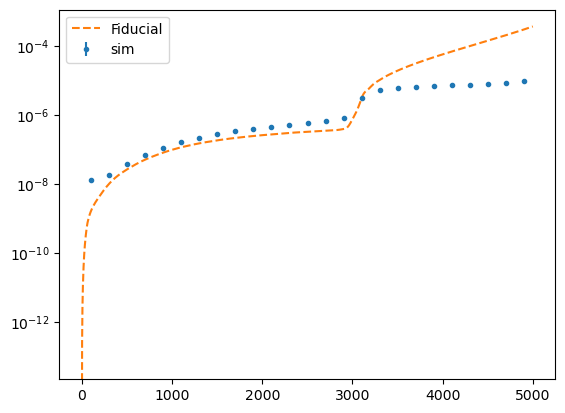

In [19]:
# Comparing auto-spectrum to theory
plt.errorbar(bins+Lmin, cl_tem, err_tem, ls="", marker=".", label="sim")
plt.semilogy(Ls, cl_kappa_pB_spline(Ls)/F_L_spline(Ls), label="Fiducial", ls="--")
plt.legend()

In [20]:
# Computing \kappa^{tem}\kappa^{pB} cross-spectrum
kappa_map_pB = field.nbody.get_kappa_map(True) - field.nbody.get_kappa_map(False)
kappa_pB_lm = field.sht.map2alm(kappa_map_pB)
cl_cross = field.sht.alm2cl(kappa_pB_lm,kappa_tem_lm)
cl_cross,_,err_cross = field.sht.bin_cl(cl_cross[Lmin:Lmax+1],nbins)

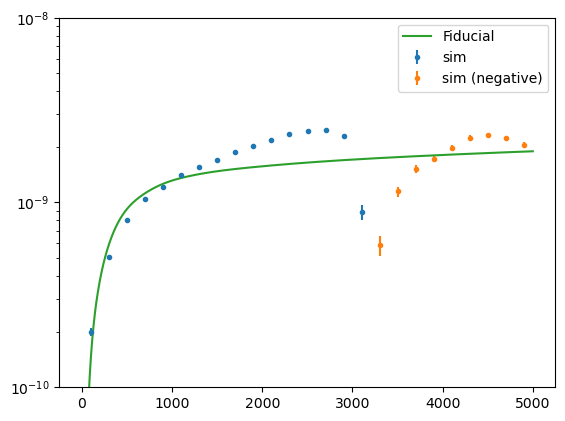

In [24]:
# Comparing cross-spectrum to theory (agreement not amazing - why?)
plt.errorbar(bins+Lmin, cl_cross, err_cross, ls="", marker=".", label="sim")
plt.errorbar(bins+Lmin, -cl_cross, err_cross, ls="", marker=".", label="sim (negative)")

plt.semilogy(Ls, cl_kappa_pB_spline(Ls), label="Fiducial")
plt.ylim(1e-10,1e-8)
plt.legend()

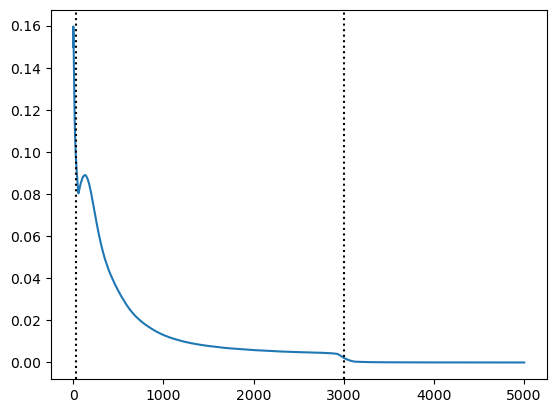

In [28]:
# Plotting F_L (tracers cut at \ell=30 and \ell=3000)
plt.plot(np.arange(1,5001), F_L_spline(np.arange(1,5001)))
plt.axvline(30, ls=":", color="k")
plt.axvline(3000, ls=":", color="k")